In [24]:
!pip install gensim tqdm

In [70]:
import pandas as pd
import pickle
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
import gensim.downloader as api
import numpy as np
from tqdm import tqdm
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, precision_score, recall_score, 
                             f1_score, roc_curve, auc, roc_auc_score)
from sklearn.preprocessing import label_binarize
from itertools import cycle
from sklearn.utils.class_weight import compute_class_weight
import time
from sklearn.metrics import auc as sk_auc

In [45]:
csv_file_path = "../data/preprocessed/"
X_train_df = pd.read_csv(csv_file_path + "X_train.csv")
X_val_df = pd.read_csv(csv_file_path + "X_val.csv")
X_test_df = pd.read_csv(csv_file_path + "X_test.csv")

y_train_df = pd.read_csv(csv_file_path + "y_train.csv")
y_val_df = pd.read_csv(csv_file_path + "y_val.csv")
y_test_df = pd.read_csv(csv_file_path + "y_test.csv")

In [46]:
with open("../Models/label_encoder.pkl", "rb") as f:
    le = pickle.load(f)

c:\Users\User\anaconda3\envs\health_risk_model\lib\site-packages\sklearn\base.py:318: UserWarning: Trying to unpickle estimator LabelEncoder from version 1.6.1 when using version 1.2.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [71]:
def plot_confusion_matrix(y_true, y_pred, labels=None):
    conf = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    xticks = labels if labels is not None else ""
    yticks = labels if labels is not None else ""
    sns.heatmap(conf, annot=True, fmt='g', cmap='Blues', cbar=False,
                xticklabels=xticks, yticklabels=yticks)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

def evaluate_model(y_true, y_pred, model_name="Model", y_proba=None, labels=None):
    print(f"\nPerformance Metrics for {model_name}:")
    print(f"Accuracy     : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision    : {precision_score(y_true, y_pred, average='weighted'):.4f}")
    print(f"Recall       : {recall_score(y_true, y_pred, average='weighted'):.4f}")
    print(f"F1 Score     : {f1_score(y_true, y_pred, average='weighted'):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=labels))
    plot_confusion_matrix(y_true, y_pred, labels=labels)

def plot_auc_curve(y_test, y_prob, class_labels=None, calledFrom='main'):
    from sklearn.preprocessing import label_binarize

    if len(np.unique(y_test)) == 2:
        fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1] if y_prob.ndim > 1 else y_prob)
        roc_auc = roc_auc_score(y_test, y_prob[:, 1] if y_prob.ndim > 1 else y_prob)
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc='lower right')
        plt.grid()
        plt.show()
    else:
        y_test_bin = label_binarize(y_test, classes=np.arange(y_prob.shape[1]))
        fpr, tpr, roc_auc = {}, {}, {}
        for i in range(y_prob.shape[1]):
            fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
            roc_auc[i] = sk_auc(fpr[i], tpr[i])  # <-- Use sk_auc here!
        all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(roc_auc))]))
        mean_tpr = np.zeros_like(all_fpr)
        for i in range(len(roc_auc)):
            mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
        mean_tpr /= len(roc_auc)
        plt.figure(figsize=(8, 6))
        from itertools import cycle
        colors = cycle(['red', 'blue', 'green', 'purple', 'orange', 'brown', 'cyan'])
        for i, color in zip(range(len(roc_auc)), colors):
            label = f'Class {class_labels[i]}' if class_labels is not None else f'Class {i}'
            plt.plot(fpr[i], tpr[i], color=color, label=f'{label} (AUC = {roc_auc[i]:.2f})')
        plt.plot(all_fpr, mean_tpr, color='black', linestyle='--',
                 label=f'Macro-Average (AUC = {sk_auc(all_fpr, mean_tpr):.2f})')
        plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Multiclass ROC Curve')
        plt.legend(loc='lower right')
        plt.grid()
        plt.show()
        roc_auc_macro = sk_auc(all_fpr, mean_tpr)
    if calledFrom == 'tuning':
        return roc_auc_macro

In [48]:
max_vocab_size = 10000
max_len = 50
embed_dim  = 100

tokenizer = Tokenizer(num_words=max_vocab_size, oov_token="<UNK>") 
tokenizer.fit_on_texts(X_train_df['clean_tweet'])

In [49]:
X_train = pad_sequences(tokenizer.texts_to_sequences(X_train_df['clean_tweet']), maxlen=max_len, padding='post')
X_val = pad_sequences(tokenizer.texts_to_sequences(X_val_df['clean_tweet']), maxlen=max_len, padding='post')
X_test = pad_sequences(tokenizer.texts_to_sequences(X_test_df['clean_tweet']), maxlen=max_len, padding='post')

In [50]:
y_train = to_categorical(le.transform(y_train_df['sentiment_consolidated']))
y_val = to_categorical(le.transform(y_val_df['sentiment_consolidated']))
y_test = to_categorical(le.transform(y_test_df['sentiment_consolidated']))
num_classes = y_train.shape[1]

In [51]:
def print_class_percentages(df, label_col="sentiment_consolidated", split_name=""):
    counts = df[label_col].value_counts()
    total = counts.sum()
    print(f"{split_name} set class distribution (percentages):")
    for label, count in counts.items():
        print(f"  {label:<10}: {count:>7} ({100*count/total:6.2f}%)")
    print()

print_class_percentages(y_train_df, "sentiment_consolidated", "Train")
print_class_percentages(y_val_df, "sentiment_consolidated", "Validation")
print_class_percentages(y_test_df, "sentiment_consolidated", "Test")


Train set class distribution (percentages):
  positive  :  178474 ( 67.44%)
  negative  :   45941 ( 17.36%)
  neutral   :   40221 ( 15.20%)

Validation set class distribution (percentages):
  positive  :   59491 ( 67.44%)
  negative  :   15314 ( 17.36%)
  neutral   :   13407 ( 15.20%)

Test set class distribution (percentages):
  positive  :   59492 ( 67.44%)
  negative  :   15314 ( 17.36%)
  neutral   :   13407 ( 15.20%)



In [52]:
print("Loading FastText vectors")
ft = api.load("fasttext-wiki-news-subwords-300")

vocab_size = min(20000, len(tokenizer.word_index) + 1)
embedding_matrix = np.zeros((vocab_size, embed_dim))
for word, i in tqdm(tokenizer.word_index.items()):
    if i >= vocab_size:
        continue
    if word in ft:
        embedding_matrix[i] = ft[word][:embed_dim]
    else:
        embedding_matrix[i] = np.random.normal(scale=0.6, size=(embed_dim,))

Loading FastText vectors


100%|██████████| 93970/93970 [00:00<00:00, 675532.47it/s]


In [53]:
class RelativePositionEmbedding(layers.Layer):
    def __init__(self, max_len, embed_dim):
        super().__init__()
        self.max_len = max_len
        self.rel_pos_emb = self.add_weight(
            shape=(2 * max_len - 1, embed_dim),
            initializer="random_normal",
            trainable=True,
            name="rel_pos_emb"
        )

    def call(self, seq_len):
        range_vec = tf.range(seq_len)
        rel_pos = tf.expand_dims(range_vec, 0) - tf.expand_dims(range_vec, 1) + self.max_len - 1
        rel_pos = tf.clip_by_value(rel_pos, 0, 2 * self.max_len - 2)
        return tf.gather(self.rel_pos_emb, rel_pos)

In [54]:
class CausalMHAWithRelPos(layers.Layer):
    def __init__(self, embed_dim, num_heads, max_len, **kwargs):
        super().__init__(**kwargs)
        self.mha = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.rel_pos = RelativePositionEmbedding(max_len, embed_dim)

    def call(self, x, training=None):
        seq_len = tf.shape(x)[1]
        rel_emb = self.rel_pos(seq_len)
        rel_emb = tf.expand_dims(rel_emb, 0)  # (1, seq_len, seq_len, emb)
        bias = tf.reduce_mean(rel_emb, axis=2)  # (1, seq_len, emb)
        x = x + bias

        mask = tf.linalg.band_part(tf.ones((seq_len, seq_len)), -1, 0)
        mask = tf.cast(mask, dtype=tf.bool)
        attn_out = self.mha(x, x, attention_mask=mask)
        return attn_out


In [55]:
def build_causal_transformer(
    vocab_size, embed_dim, max_len, num_heads, ff_dim, num_classes, embedding_matrix, num_layers=2, dropout=0.2
):
    inputs = keras.Input(shape=(max_len,), dtype=tf.int32)
    embedding = layers.Embedding(
        vocab_size,
        embed_dim,
        weights=[embedding_matrix],
        trainable=True,
        mask_zero=True,
        name="fasttext_embedding"
    )(inputs)

    x = embedding
    for _ in range(num_layers):
        attn = CausalMHAWithRelPos(embed_dim, num_heads, max_len)(x)
        x = layers.Add()([x, attn])
        x = layers.LayerNormalization()(x)
        ff = layers.Dense(ff_dim, activation="relu")(x)
        x = layers.Add()([x, ff])
        x = layers.LayerNormalization()(x)
        x = layers.Dropout(dropout)(x)

    x = layers.GlobalAveragePooling1D()(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    model = keras.Model(inputs, outputs)
    return model

model = build_causal_transformer(
    vocab_size=vocab_size,
    embed_dim=embed_dim,
    max_len=max_len,
    num_heads=4,
    ff_dim=embed_dim,
    num_classes=num_classes,
    embedding_matrix=embedding_matrix,
    num_layers=2,
    dropout=0.2,
)
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()


c:\Users\User\anaconda3\envs\health_risk_model\lib\site-packages\keras\src\layers\layer.py:932: UserWarning: Layer 'causal_mha_with_rel_pos_2' (of type CausalMHAWithRelPos) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fasttext_embedding  │ (None, 50, 100)   │  2,000,000 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ causal_mha_with_re… │ (None, 50, 100)   │    171,200 │ fasttext_embeddi… │
│ (CausalMHAWithRelP… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 50, 100)   │          0 │ fasttext_embeddi… │
│                     │                   │            │ causal_mha_with_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 50, 100)   │        200 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 50, 100)   │     10,100 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 50, 100)   │          0 │ layer_normalizat… │
│                     │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 50, 100)   │        200 │ add_5[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 50, 100)   │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ causal_mha_with_re… │ (None, 50, 100)   │    171,200 │ dropout_7[0][0]   │
│ (CausalMHAWithRelP… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 50, 100)   │          0 │ dropout_7[0][0],  │
│                     │                   │            │ causal_mha_with_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 50, 100)   │        200 │ add_6[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 50, 100)   │     10,100 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 50, 100)   │          0 │ layer_normalizat… │
│                     │                   │            │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 50, 100)   │        200 │ add_7[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 50, 100)   │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 100)       │          0 │ dropout_9[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 3)         │        303 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 2,363,703 (9.02 MB)

 Trainable params: 2,363,703 (9.02 MB)

 Non-trainable params: 0 (0.00 B)

In [56]:
y_train_int = np.argmax(y_train, axis=1)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_int),
    y=y_train_int
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

Class weights: {0: 1.9201149300189373, 1: 2.193182665771612, 2: 0.49425686654638773}


In [57]:
start_time = time.time()
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=128,
    epochs=5,
    callbacks=[keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)],
    class_weight=class_weight_dict
)
end_time = time.time()

Epoch 1/5


c:\Users\User\anaconda3\envs\health_risk_model\lib\site-packages\keras\src\layers\layer.py:932: UserWarning: Layer 'causal_mha_with_rel_pos_2' (of type CausalMHAWithRelPos) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


2068/2068 ━━━━━━━━━━━━━━━━━━━━ 610s 291ms/step - accuracy: 0.7393 - loss: 0.6925 - val_accuracy: 0.8515 - val_loss: 0.4117
Epoch 2/5
2068/2068 ━━━━━━━━━━━━━━━━━━━━ 616s 298ms/step - accuracy: 0.8400 - loss: 0.4758 - val_accuracy: 0.8515 - val_loss: 0.3991
Epoch 3/5
2068/2068 ━━━━━━━━━━━━━━━━━━━━ 790s 382ms/step - accuracy: 0.8612 - loss: 0.4197 - val_accuracy: 0.8513 - val_loss: 0.3991
Epoch 4/5
2068/2068 ━━━━━━━━━━━━━━━━━━━━ 622s 301ms/step - accuracy: 0.8733 - loss: 0.3777 - val_accuracy: 0.8624 - val_loss: 0.3889
Epoch 5/5
2068/2068 ━━━━━━━━━━━━━━━━━━━━ 635s 307ms/step - accuracy: 0.8817 - loss: 0.3450 - val_accuracy: 0.8636 - val_loss: 0.3787


In [59]:
training_time = end_time - start_time
min, sec = divmod(training_time, 60)
hr, min = divmod(min, 60)
print(f"Training Time: {hr:.0f} hour {min:.0f} min {sec:.2f} sec")

Training Time: 0 hour 54 min 34.33 sec


In [60]:
model.save('../Models/causal_tf_fasttext_model.h5')
import pickle
with open('../Models/ctfft_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

In [61]:
model = keras.models.load_model('../Models/causal_tf_fasttext_model.h5', custom_objects={
    'RelativePositionEmbedding': RelativePositionEmbedding,
    'CausalMHAWithRelPos': CausalMHAWithRelPos
})

with open('../Models/ctfft_history.pkl', 'rb') as f:
    history_dict = pickle.load(f)

2757/2757 ━━━━━━━━━━━━━━━━━━━━ 67s 24ms/step
              precision    recall  f1-score   support

           0       0.71      0.87      0.78     15314
           1       0.68      0.71      0.69     13407
           2       0.96      0.89      0.93     59492

    accuracy                           0.86     88213
   macro avg       0.78      0.82      0.80     88213
weighted avg       0.87      0.86      0.87     88213



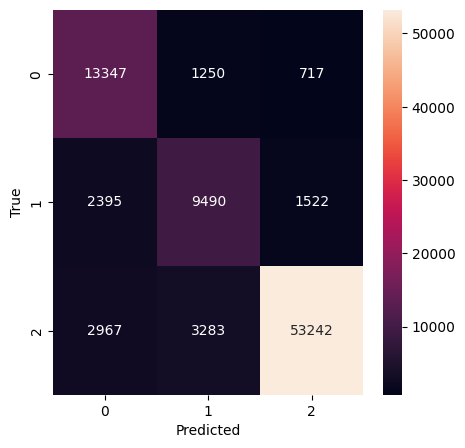

AUC: 0.9523009060822721


In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import numpy as np

preds = model.predict(X_test)
pred_labels = np.argmax(preds, axis=1)
true_labels = np.argmax(y_test, axis=1)
print(classification_report(true_labels, pred_labels))

cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

try:
    auc = roc_auc_score(y_test, preds, multi_class='ovr')
    print("AUC:", auc)
except Exception as e:
    print("AUC could not be computed for this data shape.", e)

In [63]:
train_probs = model.predict(X_train)
y_train_pred = np.argmax(train_probs, axis=1)
y_train_true = np.argmax(y_train, axis=1)

8270/8270 ━━━━━━━━━━━━━━━━━━━━ 213s 26ms/step


In [64]:
val_probs   = model.predict(X_val)
y_val_pred   = np.argmax(val_probs, axis=1)
y_val_true   = np.argmax(y_val, axis=1)

2757/2757 ━━━━━━━━━━━━━━━━━━━━ 65s 24ms/step


In [65]:
test_probs  = model.predict(X_test)
y_test_pred  = np.argmax(test_probs, axis=1)
y_test_true  = np.argmax(y_test, axis=1)

2757/2757 ━━━━━━━━━━━━━━━━━━━━ 88s 32ms/step


In [66]:
labels = list(le.classes_)



Performance Metrics for Causal Transformer (Train):
Accuracy     : 0.9033
Precision    : 0.9118
Recall       : 0.9033
F1 Score     : 0.9055

Classification Report:
              precision    recall  f1-score   support

    negative       0.78      0.94      0.85     45941
     neutral       0.78      0.81      0.79     40221
    positive       0.98      0.91      0.94    178474

    accuracy                           0.90    264636
   macro avg       0.84      0.89      0.86    264636
weighted avg       0.91      0.90      0.91    264636



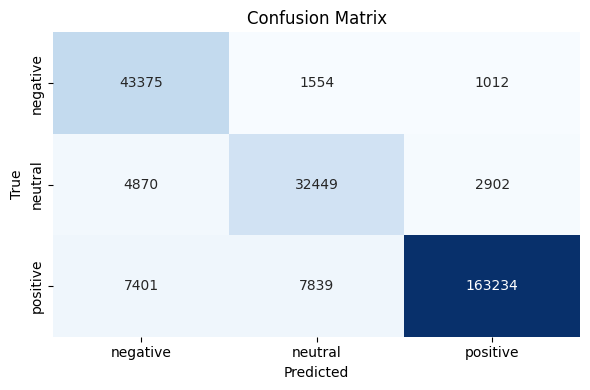

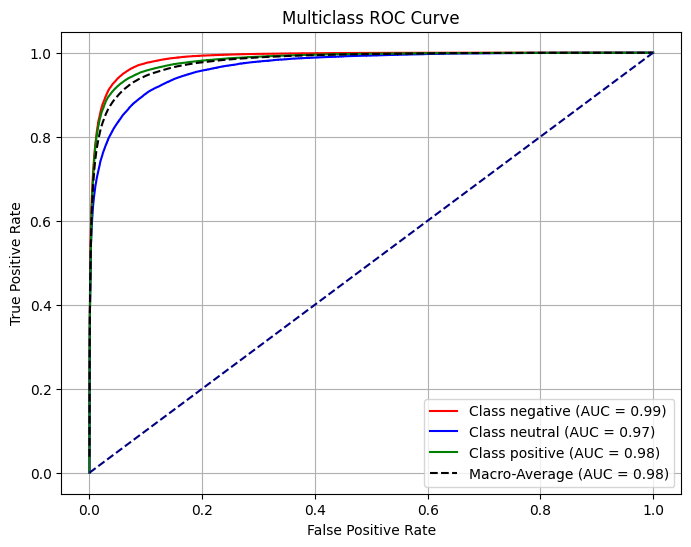

In [74]:
evaluate_model(y_train_true, y_train_pred, model_name="Causal Transformer (Train)", y_proba=train_probs, labels=labels)
plot_auc_curve(y_train_true, train_probs, class_labels=labels)


Performance Metrics for Causal Transformer (Validation):
Accuracy     : 0.8636
Precision    : 0.8743
Recall       : 0.8636
F1 Score     : 0.8670

Classification Report:
              precision    recall  f1-score   support

    negative       0.72      0.87      0.79     15314
     neutral       0.68      0.71      0.69     13407
    positive       0.96      0.90      0.93     59491

    accuracy                           0.86     88212
   macro avg       0.79      0.83      0.80     88212
weighted avg       0.87      0.86      0.87     88212



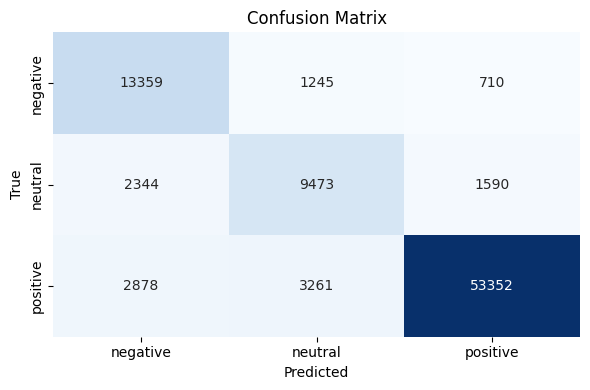

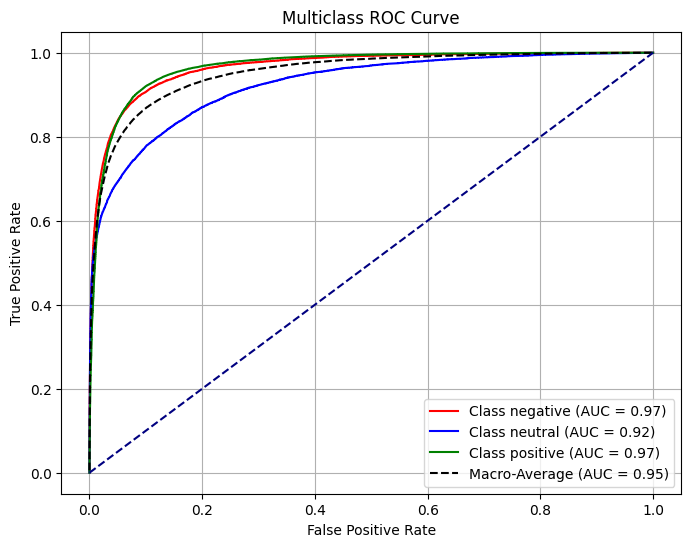

In [75]:
evaluate_model(y_val_true, y_val_pred, model_name="Causal Transformer (Validation)", y_proba=val_probs, labels=labels)
plot_auc_curve(y_val_true, val_probs, class_labels=labels)


Performance Metrics for Causal Transformer (Test):
Accuracy     : 0.8624
Precision    : 0.8739
Recall       : 0.8624
F1 Score     : 0.8660

Classification Report:
              precision    recall  f1-score   support

    negative       0.71      0.87      0.78     15314
     neutral       0.68      0.71      0.69     13407
    positive       0.96      0.89      0.93     59492

    accuracy                           0.86     88213
   macro avg       0.78      0.82      0.80     88213
weighted avg       0.87      0.86      0.87     88213



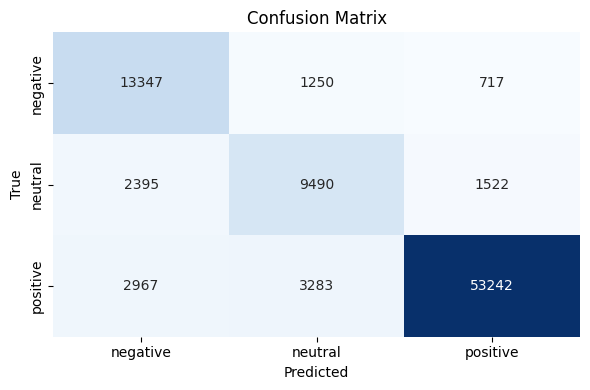

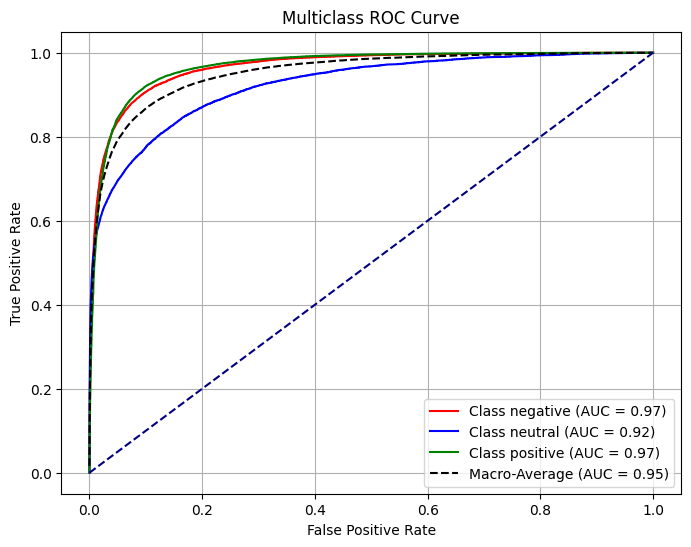

In [76]:
evaluate_model(y_test_true, y_test_pred, model_name="Causal Transformer (Test)", y_proba=test_probs, labels=labels)
plot_auc_curve(y_test_true, test_probs, class_labels=labels)